# **1) IMPORTS + CONFIGURACIÓN GLOBAL**

In [1]:
import os
import time
import math
import json
import copy
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

from torchvision import transforms
from torchvision.datasets import ImageFolder

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    accuracy_score,
    f1_score,
    precision_score,
    confusion_matrix,
    classification_report,
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

## 1.1) IDENTIDAD DEL EXPERIMENTO

In [2]:
EXPERIMENT_NAME = "CNN"
MODEL_NAME = "CNN-3"

## 1.2) SEMILLA

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True
torch.set_default_dtype(torch.float32)

## 1.3) DISPOSITIVO

In [4]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print("=" * 70)
print(f"[Experimento] {EXPERIMENT_NAME}")
print(f"[Modelo]      {MODEL_NAME}")
print("=" * 70)
print("[Device] Using:", DEVICE)
print("[CUDA available]:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("[CUDA device]:", torch.cuda.get_device_name(0))

[Experimento] CNN
[Modelo]      CNN-3
[Device] Using: cuda:0
[CUDA available]: True
[CUDA device]: NVIDIA GeForce RTX 3090


# 1.4) RUTA DEL DATASET

In [5]:
DATA_ROOT = r"C:\Users\lapic\datasets\Curated_XRay_256x256"

if not os.path.isdir(DATA_ROOT):
    raise FileNotFoundError(f"No encontré DATA_ROOT:\n{DATA_ROOT}")

print("[DATA_ROOT]", DATA_ROOT)

[DATA_ROOT] C:\Users\lapic\datasets\Curated_XRay_256x256


# 1.5) HIPERPARÁMETROS

In [6]:
IMG_SIZE = 256
IN_CHANNELS = 1

BATCH_SIZE = 16
NUM_WORKERS = 0

FRAC_TRAIN = 0.80
FRAC_VAL = 0.10

EPOCHS = 20

LATENT_DIM = 15
DROPOUT_P = 0.20

LR_CL = 1e-3
WEIGHT_DECAY = 1e-5

## 1.6) CLASIFICADOR AUXILIAR

In [7]:
AUX_CLASSIFIER = "mlp"
AUX_MLP_HIDDEN = (32, 16)
AUX_MAX_ITER = 2000
AUX_RANDOM_STATE = SEED

## 1.7) CARPETAS DE RESULTADOS

In [8]:
RESULTS_ROOT = "Results"
MODEL_RESULTS_DIR = os.path.join(RESULTS_ROOT, EXPERIMENT_NAME)

CKPT_DIR = os.path.join(MODEL_RESULTS_DIR, "checkpoints")
EMB_DIR = os.path.join(MODEL_RESULTS_DIR, "embeddings")
FIG_DIR = os.path.join(MODEL_RESULTS_DIR, "figures")
LOG_DIR = os.path.join(MODEL_RESULTS_DIR, "logs")
TABLE_DIR = os.path.join(MODEL_RESULTS_DIR, "tables")

for d in [
    RESULTS_ROOT,
    MODEL_RESULTS_DIR,
    CKPT_DIR,
    EMB_DIR,
    FIG_DIR,
    LOG_DIR,
    TABLE_DIR,
]:
    os.makedirs(d, exist_ok=True)

## 1.8) RESUMEN

In [9]:
print("\n" + "=" * 70)
print("[Resumen]")
print("=" * 70)
print("IMG_SIZE          =", IMG_SIZE)
print("IN_CHANNELS       =", IN_CHANNELS)
print("BATCH_SIZE        =", BATCH_SIZE)
print("NUM_WORKERS       =", NUM_WORKERS)
print("EPOCHS            =", EPOCHS)
print("LATENT_DIM        =", LATENT_DIM)
print("LR_CL             =", LR_CL)
print("WEIGHT_DECAY      =", WEIGHT_DECAY)
print("DROPOUT_P         =", DROPOUT_P)
print("RESULTS_ROOT      =", RESULTS_ROOT)
print("MODEL_RESULTS_DIR =", MODEL_RESULTS_DIR)
print("=" * 70)


[Resumen]
IMG_SIZE          = 256
IN_CHANNELS       = 1
BATCH_SIZE        = 16
NUM_WORKERS       = 0
EPOCHS            = 20
LATENT_DIM        = 15
LR_CL             = 0.001
WEIGHT_DECAY      = 1e-05
DROPOUT_P         = 0.2
RESULTS_ROOT      = Results
MODEL_RESULTS_DIR = Results\CNN


## **2) DATASET + TRANSFORMS + SPLITS + DATALOADERS**

## 2.1) TRANSFORMACIONES

In [10]:
train_tfms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

eval_tfms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

## 2.2) DATASET COMPLETO

In [11]:
base_ds = ImageFolder(root=DATA_ROOT, transform=None)

print("=" * 70)
print("[Dataset completo]")
print("=" * 70)
print("Clases encontradas:", base_ds.classes)
print("class_to_idx:", base_ds.class_to_idx)
print("Total imágenes:", len(base_ds))

[Dataset completo]
Clases encontradas: ['COVID-19', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']
class_to_idx: {'COVID-19': 0, 'Normal': 1, 'Pneumonia-Bacterial': 2, 'Pneumonia-Viral': 3}
Total imágenes: 9209


## 2.3) SELECCIÓN COVID VS NORMAL

In [12]:
POSITIVE_CLASS_CANDIDATES = ["COVID-19", "COVID", "Covid", "covid", "COVID19"]
NEGATIVE_CLASS_CANDIDATES = ["Normal", "NORMAL", "normal"]

def find_class_name(candidates, available_classes):
    for c in candidates:
        if c in available_classes:
            return c
    raise ValueError(f"No encontré ninguna clase de {candidates} en {available_classes}")

positive_class = find_class_name(POSITIVE_CLASS_CANDIDATES, base_ds.classes)
negative_class = find_class_name(NEGATIVE_CLASS_CANDIDATES, base_ds.classes)

positive_idx = base_ds.class_to_idx[positive_class]
negative_idx = base_ds.class_to_idx[negative_class]

print("\n[Clasificación binaria]")
print(f"Clase positiva y=1: {positive_class} | idx original={positive_idx}")
print(f"Clase negativa y=0: {negative_class} | idx original={negative_idx}")


[Clasificación binaria]
Clase positiva y=1: COVID-19 | idx original=0
Clase negativa y=0: Normal | idx original=1


## 2.4) DATASET BINARIO

In [13]:
class BinaryImageFolder(Dataset):

    def __init__(self, base_ds, positive_idx, negative_idx, transform=None):
        self.base_ds = base_ds
        self.positive_idx = positive_idx
        self.negative_idx = negative_idx
        self.transform = transform
        self.samples = []

        for path, y_original in self.base_ds.samples:
            if y_original == positive_idx:
                self.samples.append((path, 1))
            elif y_original == negative_idx:
                self.samples.append((path, 0))

        if len(self.samples) == 0:
            raise RuntimeError("No se encontraron imágenes para las clases seleccionadas.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, y = self.samples[idx]
        img = self.base_ds.loader(path)

        if self.transform is not None:
            img = self.transform(img)

        y = torch.tensor(y, dtype=torch.float32)
        return img, y


binary_ds = BinaryImageFolder(
    base_ds=base_ds,
    positive_idx=positive_idx,
    negative_idx=negative_idx,
    transform=train_tfms,
)

labels_all = np.array([y for _, y in binary_ds.samples]).astype(int)

n_total = len(labels_all)
n_pos = int(labels_all.sum())
n_neg = int(n_total - n_pos)

print("\n[Dataset binario]")
print("Total:", n_total)
print(f"Negativos y=0 ({negative_class}):", n_neg)
print(f"Positivos y=1 ({positive_class}):", n_pos)
print(f"Proporción positivos: {100*n_pos/n_total:.2f}%")


[Dataset binario]
Total: 4552
Negativos y=0 (Normal): 3271
Positivos y=1 (COVID-19): 1281
Proporción positivos: 28.14%


## 2.5) SPLITS ESTRATIFICADOS

In [14]:
indices = np.arange(len(binary_ds))
targets = labels_all

idx_train, idx_tmp, y_train_split, y_tmp = train_test_split(
    indices,
    targets,
    train_size=FRAC_TRAIN,
    random_state=SEED,
    stratify=targets,
)

val_fraction_of_tmp = FRAC_VAL / (1.0 - FRAC_TRAIN)

idx_val, idx_test, y_val_split, y_test_split = train_test_split(
    idx_tmp,
    y_tmp,
    train_size=val_fraction_of_tmp,
    random_state=SEED,
    stratify=y_tmp,
)

train_ds = Subset(binary_ds, idx_train)
val_ds   = Subset(binary_ds, idx_val)
test_ds  = Subset(binary_ds, idx_test)


def split_report(name, idxs):
    ys = labels_all[idxs].astype(int)
    total = len(ys)
    pos = int(ys.sum())
    neg = total - pos

    print(
        f"{name:>5}: total={total:5d} | "
        f"y=0 {neg:5d} | y=1 {pos:5d} | "
        f"pos={100*pos/total:5.2f}%"
    )

print("\n[Splits]")
split_report("train", idx_train)
split_report("val", idx_val)
split_report("test", idx_test)


[Splits]
train: total= 3641 | y=0  2616 | y=1  1025 | pos=28.15%
  val: total=  455 | y=0   327 | y=1   128 | pos=28.13%
 test: total=  456 | y=0   328 | y=1   128 | pos=28.07%


## 2.6) DATALOADERS

In [15]:
g_cpu = torch.Generator(device="cpu")
g_cpu.manual_seed(SEED)

loader_kwargs_train = dict(
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=g_cpu,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

loader_kwargs_eval = dict(
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

if NUM_WORKERS > 0:
    loader_kwargs_train["persistent_workers"] = True
    loader_kwargs_eval["persistent_workers"] = True
    loader_kwargs_train["prefetch_factor"] = 2
    loader_kwargs_eval["prefetch_factor"] = 2

train_loader = DataLoader(train_ds, **loader_kwargs_train)
val_loader   = DataLoader(val_ds, **loader_kwargs_eval)
test_loader  = DataLoader(test_ds, **loader_kwargs_eval)

print("\n[DataLoaders]")
print(f"NUM_WORKERS   = {NUM_WORKERS}")
print(f"BATCH_SIZE    = {BATCH_SIZE}")
print(f"Train batches = {len(train_loader)}")
print(f"Val batches   = {len(val_loader)}")
print(f"Test batches  = {len(test_loader)}")


[DataLoaders]
NUM_WORKERS   = 0
BATCH_SIZE    = 16
Train batches = 228
Val batches   = 29
Test batches  = 29


## 2.7) SANITY BATCH

In [16]:
xb, yb = next(iter(train_loader))

print("\n[Sanity batch]")
print("x shape:", xb.shape)
print("y shape:", yb.shape)
print("x dtype:", xb.dtype)
print("y dtype:", yb.dtype)
print("x min/max:", float(xb.min()), float(xb.max()))
print("y unique:", torch.unique(yb))


[Sanity batch]
x shape: torch.Size([16, 1, 256, 256])
y shape: torch.Size([16])
x dtype: torch.float32
y dtype: torch.float32
x min/max: -1.0 1.0
y unique: tensor([0., 1.])


# **3) MÉTRICAS + CHECKPOINTS + GRÁFICAS**

## 3.1) UTILIDADES GENERALES

In [17]:
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def clone_state_dict_cpu(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}


def sigmoid_np(logits):
    return 1.0 / (1.0 + np.exp(-logits))

## 3.2) MÉTRICAS BINARIAS

In [18]:
def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)


def safe_pr_auc(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return average_precision_score(y_true, y_score)


def binary_metrics_from_probs(y_true, probs, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    probs = np.asarray(probs).astype(float)

    y_pred = (probs >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn + 1e-12)
    specificity = tn / (tn + fp + 1e-12)
    bacc = 0.5 * (sensitivity + specificity)

    return {
        "threshold": float(threshold),
        "acc": float(acc),
        "f1": float(f1),
        "precision": float(prec),
        "bacc": float(bacc),
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "pred1": float(y_pred.mean()),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

## 3.3) THRESHOLD ÓPTIMO

In [19]:
def find_best_threshold(y_true, probs, metric="bacc"):
    probs = np.asarray(probs).astype(float)
    thresholds = np.unique(probs)

    if len(thresholds) > 1000:
        thresholds = np.linspace(0.0, 1.0, 1001)

    best_thr = 0.5
    best_val = -np.inf
    best_metrics = None

    for thr in thresholds:
        m = binary_metrics_from_probs(y_true, probs, threshold=thr)
        val = m[metric]

        if val > best_val:
            best_val = val
            best_thr = float(thr)
            best_metrics = m

    return best_thr, best_metrics

## 3.4) EVALUACIÓN COMPLETA

In [20]:
def evaluate_binary_outputs(y_true, logits_or_probs, from_logits=True):
    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(logits_or_probs).astype(float)

    probs = sigmoid_np(scores) if from_logits else scores

    auc = safe_auc(y_true, probs)
    pr_auc = safe_pr_auc(y_true, probs)

    m05 = binary_metrics_from_probs(y_true, probs, threshold=0.5)
    thr_star, mstar = find_best_threshold(y_true, probs, metric="bacc")

    return {
        "auc": float(auc),
        "pr_auc": float(pr_auc),
        "probs": probs,
        "m05": m05,
        "thr_star": float(thr_star),
        "mstar": mstar,
    }

## 3.5) FORMATO DE IMPRESIÓN

In [21]:
def format_epoch_line(epoch, dt, train_loss, train_acc05, val_loss, val_eval, lr_q, lr_cl):
    m05 = val_eval["m05"]
    ms = val_eval["mstar"]

    return (
        f"Época {epoch:02d} (dt={dt:.1f}s) | "
        f"Train loss={train_loss:.4f} "
        f"acc@0.5={100*train_acc05:.1f}% | "
        f"Val loss={val_loss:.4f} "
        f"AUC={val_eval['auc']:.3f} "
        f"PR-AUC={val_eval['pr_auc']:.3f} | "
        f"@0.5 acc={100*m05['acc']:.1f}% "
        f"F1={m05['f1']:.3f} "
        f"bAcc={m05['bacc']:.3f} "
        f"pred1={100*m05['pred1']:.1f}% | "
        f"@thr* acc={100*ms['acc']:.1f}% "
        f"F1={ms['f1']:.3f} "
        f"bAcc={ms['bacc']:.3f} "
        f"pred1={100*ms['pred1']:.1f}% "
        f"thr={val_eval['thr_star']:.3f} | "
        f"LR_Q={lr_q:.2e} | "
        f"LR_CL={lr_cl:.2e}"
    )

## 3.6) CHECKPOINTS

In [22]:
def save_checkpoint(path, model, optimizer, epoch, metrics, threshold=None):
    payload = {
        "experiment_name": EXPERIMENT_NAME,
        "model_name": MODEL_NAME,
        "epoch": epoch,
        "model_state_dict": clone_state_dict_cpu(model),
        "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
        "metrics": metrics,
        "threshold": threshold,
    }

    torch.save(payload, path)


def load_model_state_from_checkpoint(model, path, map_location=DEVICE):
    ckpt = torch.load(path, map_location=map_location)
    model.load_state_dict(ckpt["model_state_dict"])
    return ckpt

## 3.7) GRÁFICAS

In [23]:
def plot_history(history, fig_dir=FIG_DIR, prefix="fase1"):
    df = pd.DataFrame(history)

    if len(df) == 0:
        return

    plt.figure(figsize=(7, 5))
    plt.plot(df["epoch"], df["train_loss"], marker="o", label="Train")
    plt.plot(df["epoch"], df["val_loss"], marker="o", label="Val")
    plt.title(f"{MODEL_NAME} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir, f"{prefix}_loss.png"), dpi=160)
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(df["epoch"], 100 * df["train_acc05"], marker="o", label="Train")
    plt.plot(df["epoch"], 100 * df["val_acc05"], marker="o", label="Val @0.5")
    plt.plot(df["epoch"], 100 * df["val_acc_thr"], marker="o", label="Val @thr*")
    plt.title(f"{MODEL_NAME} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir, f"{prefix}_accuracy.png"), dpi=160)
    plt.show()

## 3.8) GUARDAR CONFIG

In [24]:
config_path = os.path.join(LOG_DIR, "config.json")

config_dict = {
    "experiment_name": EXPERIMENT_NAME,
    "model_name": MODEL_NAME,
    "seed": SEED,
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "latent_dim": LATENT_DIM,
}

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config_dict, f, indent=2, ensure_ascii=False)

print("=" * 70)
print("[OK] Sección 3 lista")
print("Config:", config_path)
print("=" * 70)

[OK] Sección 3 lista
Config: Results\CNN\logs\config.json


# **4) BLOQUES CLÁSICOS CNN**

## 4.1) BLOQUE CLÁSICO CON DOWNSAMPLING

In [25]:
class ClassicalStage(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


print("=" * 70)
print("[OK] Sección 4 lista: bloques clásicos definidos.")
print("=" * 70)

[OK] Sección 4 lista: bloques clásicos definidos.


# **5) ARQUITECTURA CNN-3**

## 5.1) CNN-3

In [26]:
class CNN3(nn.Module):

    def __init__(self, latent_dim=15, dropout_p=0.20):
        super().__init__()

        # Stage 1:
        # 1x256x256 -> 16x128x128
        self.stage1 = ClassicalStage(
            in_channels=1,
            out_channels=16
        )

        # Stage 2:
        # 16x128x128 -> 32x64x64
        self.stage2 = ClassicalStage(
            in_channels=16,
            out_channels=32
        )

        # Stage 3:
        # 32x64x64 -> 32x32x32
        self.stage3 = ClassicalStage(
            in_channels=32,
            out_channels=32
        )

        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        self.latent = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_p),
            nn.Linear(64, latent_dim)
        )

        self.head = nn.Linear(latent_dim, 1)

    def extract_features(self, x):
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)

        x = self.gap(x)

        z15 = self.latent(x)

        return z15

    def forward(self, x, return_z=False):
        z15 = self.extract_features(x)
        logits = self.head(z15).squeeze(1)

        if return_z:
            return logits, z15

        return logits

## 5.2) CREAR MODELO

In [27]:
model = CNN3(
    latent_dim=LATENT_DIM,
    dropout_p=DROPOUT_P
).to(DEVICE)

total_params, trainable_params = count_parameters(model)

print("=" * 70)
print("[CNN-3]")
print("=" * 70)
print(f"Total params     : {total_params:,}")
print(f"Trainable params : {trainable_params:,}")
print("=" * 70)

[CNN-3]
Total params     : 19,695
Trainable params : 19,695


## 5.3) OPTIMIZADOR Y LOSS

In [28]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR_CL,
    weight_decay=WEIGHT_DECAY
)

criterion = nn.BCEWithLogitsLoss()

print("\n[OK] Sección 5 lista.")


[OK] Sección 5 lista.


# **6) FASE 1: ENTRENAR RED COMPLETA**
    Imagen -> CNN-3 -> z15 -> head propia

## 6.1) FUNCIONES TRAIN / EVAL

In [29]:
def train_one_epoch(model, loader, optimizer, criterion, device):

    model.train()

    running_loss = 0.0
    all_logits = []
    all_targets = []

    for xb, yb in loader:

        xb = xb.to(device, non_blocking=True).float()
        yb = yb.to(device, non_blocking=True).float()

        optimizer.zero_grad(set_to_none=True)

        logits = model(xb)
        loss = criterion(logits, yb)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        running_loss += loss.item() * xb.size(0)

        all_logits.append(logits.detach().cpu())
        all_targets.append(yb.detach().cpu())

    epoch_loss = running_loss / len(loader.dataset)

    all_logits = torch.cat(all_logits).numpy()
    all_targets = torch.cat(all_targets).numpy().astype(int)

    probs = sigmoid_np(all_logits)

    m05 = binary_metrics_from_probs(
        all_targets,
        probs,
        threshold=0.5
    )

    return epoch_loss, m05["acc"]


@torch.no_grad()
def evaluate_model(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    all_logits = []
    all_targets = []

    for xb, yb in loader:

        xb = xb.to(device, non_blocking=True).float()
        yb = yb.to(device, non_blocking=True).float()

        logits = model(xb)
        loss = criterion(logits, yb)

        running_loss += loss.item() * xb.size(0)

        all_logits.append(logits.detach().cpu())
        all_targets.append(yb.detach().cpu())

    epoch_loss = running_loss / len(loader.dataset)

    all_logits = torch.cat(all_logits).numpy()
    all_targets = torch.cat(all_targets).numpy().astype(int)

    eval_res = evaluate_binary_outputs(
        y_true=all_targets,
        logits_or_probs=all_logits,
        from_logits=True
    )

    eval_res["loss"] = float(epoch_loss)
    eval_res["targets"] = all_targets
    eval_res["logits"] = all_logits

    return epoch_loss, eval_res

## 6.2) CHECKPOINTS

In [30]:
history = []

best_ckpts = {

    "val_loss": {
        "score": np.inf,
        "path": os.path.join(CKPT_DIR, "best_val_loss.pt")
    },

    "val_auc": {
        "score": -np.inf,
        "path": os.path.join(CKPT_DIR, "best_val_auc.pt")
    },

    "val_bacc_thr": {
        "score": -np.inf,
        "path": os.path.join(CKPT_DIR, "best_val_bacc_thr.pt")
    }
}

## 6.3) ENTRENAMIENTO PRINCIPAL

In [31]:
print("=" * 70)
print("[FASE 1] Entrenamiento red completa CNN")
print("=" * 70)

global_t0 = time.time()

for epoch in range(1, EPOCHS + 1):

    t0 = time.time()

    train_loss, train_acc05 = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=DEVICE
    )

    val_loss, val_eval = evaluate_model(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=DEVICE
    )

    dt = time.time() - t0

    lr_now = optimizer.param_groups[0]["lr"]

    print(
        format_epoch_line(
            epoch=epoch,
            dt=dt,
            train_loss=train_loss,
            train_acc05=train_acc05,
            val_loss=val_loss,
            val_eval=val_eval,
            lr_q=0.0,
            lr_cl=lr_now
        ),
        flush=True
    )

    row = {
        "epoch": epoch,
        "dt": dt,

        "train_loss": train_loss,
        "train_acc05": train_acc05,

        "val_loss": val_loss,
        "val_auc": val_eval["auc"],
        "val_pr_auc": val_eval["pr_auc"],

        "val_acc05": val_eval["m05"]["acc"],
        "val_f105": val_eval["m05"]["f1"],
        "val_bacc05": val_eval["m05"]["bacc"],
        "val_pred105": val_eval["m05"]["pred1"],

        "val_thr_star": val_eval["thr_star"],

        "val_acc_thr": val_eval["mstar"]["acc"],
        "val_f1_thr": val_eval["mstar"]["f1"],
        "val_bacc_thr": val_eval["mstar"]["bacc"],
        "val_pred1_thr": val_eval["mstar"]["pred1"],

        "lr_q": 0.0,
        "lr_cl": lr_now,
    }

    history.append(row)

    metrics_for_ckpt = {
        k: float(v)
        for k, v in row.items()
        if isinstance(v, (int, float, np.integer, np.floating))
    }

    if val_loss < best_ckpts["val_loss"]["score"]:

        best_ckpts["val_loss"]["score"] = val_loss

        save_checkpoint(
            path=best_ckpts["val_loss"]["path"],
            model=model,
            optimizer=optimizer,
            epoch=epoch,
            metrics=metrics_for_ckpt,
            threshold=val_eval["thr_star"]
        )

    if val_eval["auc"] > best_ckpts["val_auc"]["score"]:

        best_ckpts["val_auc"]["score"] = val_eval["auc"]

        save_checkpoint(
            path=best_ckpts["val_auc"]["path"],
            model=model,
            optimizer=optimizer,
            epoch=epoch,
            metrics=metrics_for_ckpt,
            threshold=val_eval["thr_star"]
        )

    if val_eval["mstar"]["bacc"] > best_ckpts["val_bacc_thr"]["score"]:

        best_ckpts["val_bacc_thr"]["score"] = val_eval["mstar"]["bacc"]

        save_checkpoint(
            path=best_ckpts["val_bacc_thr"]["path"],
            model=model,
            optimizer=optimizer,
            epoch=epoch,
            metrics=metrics_for_ckpt,
            threshold=val_eval["thr_star"]
        )

[FASE 1] Entrenamiento red completa CNN
Época 01 (dt=26.4s) | Train loss=0.2876 acc@0.5=88.1% | Val loss=0.1256 AUC=0.988 PR-AUC=0.975 | @0.5 acc=96.0% F1=0.926 bAcc=0.937 pred1=25.5% | @thr* acc=96.3% F1=0.936 bAcc=0.964 pred1=30.1% thr=0.184 | LR_Q=0.00e+00 | LR_CL=1.00e-03
Época 02 (dt=20.0s) | Train loss=0.1413 acc@0.5=95.2% | Val loss=0.1247 AUC=0.985 PR-AUC=0.971 | @0.5 acc=95.8% F1=0.925 bAcc=0.945 pred1=27.5% | @thr* acc=95.4% F1=0.923 bAcc=0.963 pred1=31.9% thr=0.078 | LR_Q=0.00e+00 | LR_CL=1.00e-03
Época 03 (dt=20.1s) | Train loss=0.1290 acc@0.5=95.7% | Val loss=0.9221 AUC=0.950 PR-AUC=0.899 | @0.5 acc=78.0% F1=0.367 bAcc=0.612 pred1=6.6% | @thr* acc=89.5% F1=0.827 bAcc=0.896 pred1=33.0% thr=0.003 | LR_Q=0.00e+00 | LR_CL=1.00e-03
Época 04 (dt=20.7s) | Train loss=0.1211 acc@0.5=96.3% | Val loss=0.1035 AUC=0.993 PR-AUC=0.984 | @0.5 acc=97.1% F1=0.948 bAcc=0.959 pred1=27.0% | @thr* acc=96.9% F1=0.947 bAcc=0.971 pred1=29.9% thr=0.099 | LR_Q=0.00e+00 | LR_CL=1.00e-03
Época 05 (dt=

## 6.4) GUARDAR HISTORIAL

In [32]:
total_time = time.time() - global_t0

history_df = pd.DataFrame(history)

history_csv = os.path.join(LOG_DIR, "fase1_history.csv")
history_json = os.path.join(LOG_DIR, "fase1_history.json")

history_df.to_csv(history_csv, index=False)

with open(history_json, "w", encoding="utf-8") as f:
    json.dump(history, f, indent=2, ensure_ascii=False)

## 6.5) RESUMEN FINAL

In [33]:
print("\n" + "=" * 70)
print("[FASE 1 terminada]")
print("=" * 70)
print(f"Tiempo total: {total_time/60:.2f} min")

print("\n[Mejores checkpoints]")

for key, info in best_ckpts.items():
    print(
        f"{key:15s} "
        f"score={info['score']:.5f} | "
        f"path={info['path']}"
    )

print("\n[Historial guardado]")
print(history_csv)
print(history_json)


[FASE 1 terminada]
Tiempo total: 6.88 min

[Mejores checkpoints]
val_loss        score=0.06127 | path=Results\CNN\checkpoints\best_val_loss.pt
val_auc         score=0.99763 | path=Results\CNN\checkpoints\best_val_auc.pt
val_bacc_thr    score=0.98760 | path=Results\CNN\checkpoints\best_val_bacc_thr.pt

[Historial guardado]
Results\CNN\logs\fase1_history.csv
Results\CNN\logs\fase1_history.json


## 6.6) GRÁFICAS

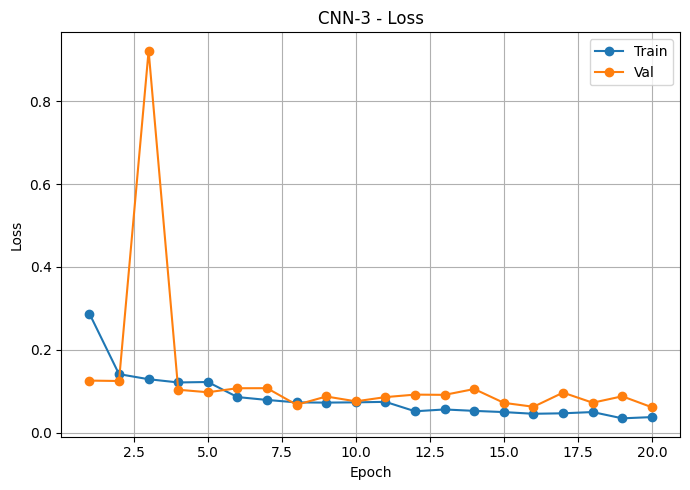

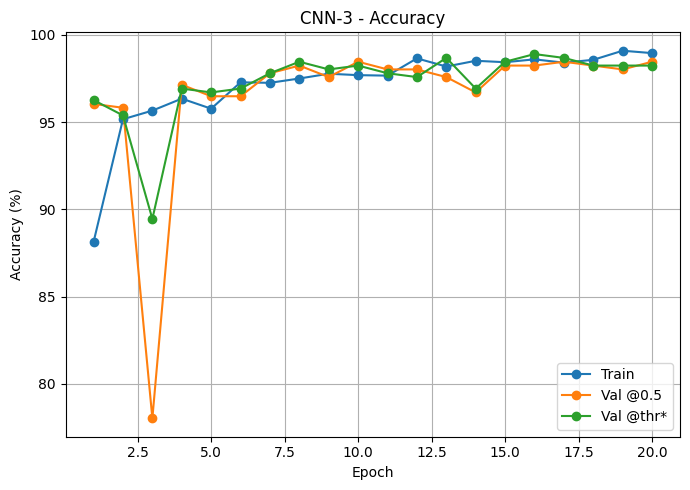

In [34]:
plot_history(
    history=history,
    fig_dir=FIG_DIR,
    prefix="fase1"
)

# **7) FASE 1: EVALUACIÓN FINAL EN TEST**
    Modelo completo: Imagen -> CNN-3 -> z15 -> head propia

## 7.0) FUNCIÓN PARA CURVAS ROC / PR Y MATRIZ DE CONFUSIÓN

In [35]:
def plot_eval_curves(
    y_true,
    probs,
    threshold,
    split_name="test",
    fig_dir=FIG_DIR,
    prefix="fase1"
):

    y_true = np.asarray(y_true).astype(int)
    probs = np.asarray(probs).astype(float)

    if len(np.unique(y_true)) == 2:

        fpr, tpr, _ = roc_curve(y_true, probs)
        auc = safe_auc(y_true, probs)

        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
        plt.plot([0, 1], [0, 1], "--")
        plt.xlabel("FPR")
        plt.ylabel("TPR")
        plt.title(f"{MODEL_NAME} - ROC {split_name}")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

        path = os.path.join(
            fig_dir,
            f"{prefix}_{split_name}_roc.png"
        )

        plt.savefig(path, dpi=160)
        plt.show()

        print("[Guardado]", path)

        prec, rec, _ = precision_recall_curve(y_true, probs)
        pr_auc = safe_pr_auc(y_true, probs)

        plt.figure(figsize=(6, 5))
        plt.plot(rec, prec, label=f"PR-AUC={pr_auc:.3f}")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"{MODEL_NAME} - Precision-Recall {split_name}")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

        path = os.path.join(
            fig_dir,
            f"{prefix}_{split_name}_pr.png"
        )

        plt.savefig(path, dpi=160)
        plt.show()

        print("[Guardado]", path)

    y_pred = (probs >= threshold).astype(int)

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )

    plt.figure(figsize=(5, 4))
    plt.imshow(cm, cmap="Blues")
    plt.title(f"{MODEL_NAME} - Confusion matrix {split_name}")
    plt.colorbar()

    plt.xticks(
        [0, 1],
        ["Normal", "COVID"]
    )

    plt.yticks(
        [0, 1],
        ["Normal", "COVID"]
    )

    for i in range(2):
        for j in range(2):
            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center",
                color="black"
            )

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()

    path = os.path.join(
        fig_dir,
        f"{prefix}_{split_name}_cm.png"
    )

    plt.savefig(path, dpi=160)
    plt.show()

    print("[Guardado]", path)

## 7.1) SELECCIONAR CHECKPOINT


In [36]:
BEST_CRITERION = "val_bacc_thr"   # opciones: "val_loss", "val_auc", "val_bacc_thr"

best_ckpt_path = best_ckpts[BEST_CRITERION]["path"]

print("=" * 70)
print("[FASE 1 - TEST] Evaluación final CNN")
print("=" * 70)
print("Checkpoint seleccionado:", BEST_CRITERION)
print("Ruta:", best_ckpt_path)

[FASE 1 - TEST] Evaluación final CNN
Checkpoint seleccionado: val_bacc_thr
Ruta: Results\CNN\checkpoints\best_val_bacc_thr.pt


## 7.2) CARGAR MEJOR CHECKPOINT

In [37]:
ckpt = load_model_state_from_checkpoint(
    model=model,
    path=best_ckpt_path,
    map_location=DEVICE
)

best_epoch = ckpt["epoch"]
best_threshold = ckpt["threshold"]

print("\n[Checkpoint cargado]")
print("Época:", best_epoch)
print("Threshold guardado:", best_threshold)
print("Métricas val:", ckpt["metrics"])


[Checkpoint cargado]
Época: 16
Threshold guardado: 0.22600846150351311
Métricas val: {'epoch': 16.0, 'dt': 20.329099893569946, 'train_loss': 0.045496605570951545, 'train_acc05': 0.9859928591046416, 'val_loss': 0.062439247590980934, 'val_auc': 0.9974675076452599, 'val_pr_auc': 0.9941268897932972, 'val_acc05': 0.9824175824175824, 'val_f105': 0.968503937007874, 'val_bacc05': 0.9758815940366921, 'val_pred105': 0.27692307692307694, 'val_thr_star': 0.22600846150351311, 'val_acc_thr': 0.989010989010989, 'val_f1_thr': 0.980544747081712, 'val_bacc_thr': 0.9876003440366918, 'val_pred1_thr': 0.2835164835164835, 'lr_q': 0.0, 'lr_cl': 0.001}


C:\Users\lapic\AppData\Local\Temp\ipykernel_10888\741509467.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path, map_location=map_location)


## 7.3) EVALUAR VALIDACIÓN Y TEST

In [38]:
val_loss_final, val_eval_final = evaluate_model(
    model=model,
    loader=val_loader,
    criterion=criterion,
    device=DEVICE
)

test_loss, test_eval = evaluate_model(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=DEVICE
)

y_test = test_eval["targets"]
p_test = test_eval["probs"]

m_test_05 = test_eval["m05"]
m_test_thr = binary_metrics_from_probs(
    y_true=y_test,
    probs=p_test,
    threshold=best_threshold
)

print("\n" + "=" * 70)
print("[RESULTADOS TEST - CNN]")
print("=" * 70)

print(f"Test loss  : {test_loss:.4f}")
print(f"Test AUC   : {test_eval['auc']:.4f}")
print(f"Test PR-AUC: {test_eval['pr_auc']:.4f}")

print("\n[@ threshold = 0.5]")
print(m_test_05)

print(f"\n[@ threshold val* = {best_threshold:.4f}]")
print(m_test_thr)


[RESULTADOS TEST - CNN]
Test loss  : 0.0398
Test AUC   : 0.9993
Test PR-AUC: 0.9980

[@ threshold = 0.5]
{'threshold': 0.5, 'acc': 0.9890350877192983, 'f1': 0.9802371541501976, 'precision': 0.992, 'bacc': 0.9828506097560923, 'sensitivity': 0.9687499999999925, 'specificity': 0.996951219512192, 'pred1': 0.2741228070175439, 'tn': 327, 'fp': 1, 'fn': 4, 'tp': 124}

[@ threshold val* = 0.2260]
{'threshold': 0.22600846150351311, 'acc': 0.993421052631579, 'f1': 0.9882352941176471, 'precision': 0.9921259842519685, 'bacc': 0.9906631097560922, 'sensitivity': 0.9843749999999923, 'specificity': 0.996951219512192, 'pred1': 0.27850877192982454, 'tn': 327, 'fp': 1, 'fn': 2, 'tp': 126}


## 7.4) MATRIZ DE CONFUSIÓN Y REPORTE


In [39]:
y_pred_test = (p_test >= best_threshold).astype(int)

cm_test = confusion_matrix(
    y_test,
    y_pred_test,
    labels=[0, 1]
)

print("\n[Confusion matrix TEST]")
print(cm_test)

print("\n[Classification report TEST]")
print(
    classification_report(
        y_test,
        y_pred_test,
        target_names=["Normal", "COVID"],
        digits=4,
        zero_division=0
    )
)


[Confusion matrix TEST]
[[327   1]
 [  2 126]]

[Classification report TEST]
              precision    recall  f1-score   support

      Normal     0.9939    0.9970    0.9954       328
       COVID     0.9921    0.9844    0.9882       128

    accuracy                         0.9934       456
   macro avg     0.9930    0.9907    0.9918       456
weighted avg     0.9934    0.9934    0.9934       456



## 7.5) GRÁFICAS TEST


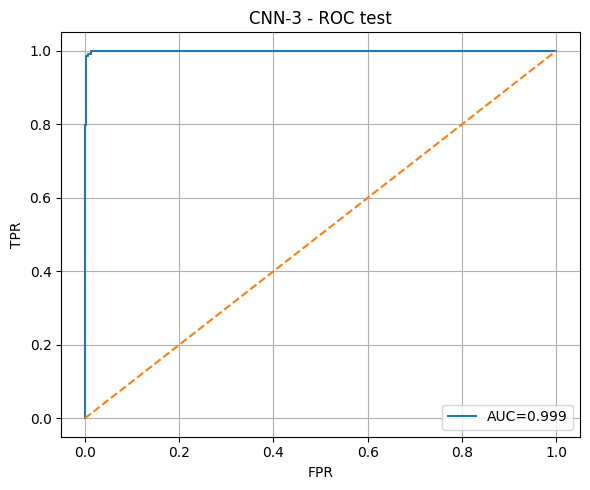

[Guardado] Results\CNN\figures\fase1_test_roc.png


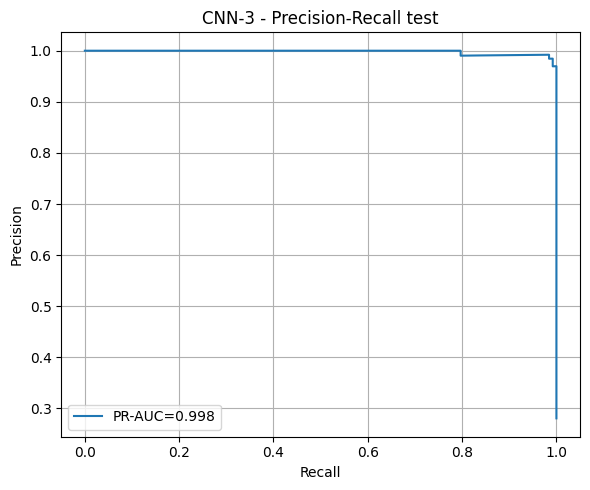

[Guardado] Results\CNN\figures\fase1_test_pr.png


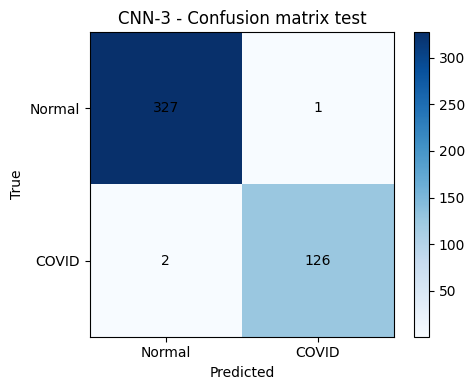

[Guardado] Results\CNN\figures\fase1_test_cm.png


In [40]:
plot_eval_curves(
    y_true=y_test,
    probs=p_test,
    threshold=best_threshold,
    split_name="test",
    fig_dir=FIG_DIR,
    prefix="fase1"
)

## 7.6) GUARDAR MÉTRICAS TEST

In [41]:
test_summary = {
    "model_name": MODEL_NAME,
    "best_criterion": BEST_CRITERION,
    "best_epoch": int(best_epoch),
    "best_threshold": float(best_threshold),

    "test_loss": float(test_loss),
    "test_auc": float(test_eval["auc"]),
    "test_pr_auc": float(test_eval["pr_auc"]),

    "test_acc_05": float(m_test_05["acc"]),
    "test_f1_05": float(m_test_05["f1"]),
    "test_bacc_05": float(m_test_05["bacc"]),

    "test_acc_thr": float(m_test_thr["acc"]),
    "test_f1_thr": float(m_test_thr["f1"]),
    "test_bacc_thr": float(m_test_thr["bacc"]),
    "test_precision_thr": float(m_test_thr["precision"]),
    "test_sensitivity_thr": float(m_test_thr["sensitivity"]),
    "test_specificity_thr": float(m_test_thr["specificity"]),
    "test_pred1_thr": float(m_test_thr["pred1"]),

    "tn": int(m_test_thr["tn"]),
    "fp": int(m_test_thr["fp"]),
    "fn": int(m_test_thr["fn"]),
    "tp": int(m_test_thr["tp"]),
}

test_summary_path_json = os.path.join(
    LOG_DIR,
    "fase1_test_summary.json"
)

test_summary_path_csv = os.path.join(
    TABLE_DIR,
    "fase1_test_summary.csv"
)

with open(test_summary_path_json, "w", encoding="utf-8") as f:
    json.dump(
        test_summary,
        f,
        indent=2,
        ensure_ascii=False
    )

pd.DataFrame([test_summary]).to_csv(
    test_summary_path_csv,
    index=False
)

print("\n[Guardado]")
print(test_summary_path_json)
print(test_summary_path_csv)

print("\n[OK] Sección 7 terminada.")


[Guardado]
Results\CNN\logs\fase1_test_summary.json
Results\CNN\tables\fase1_test_summary.csv

[OK] Sección 7 terminada.


# **8) FASE 2: CONGELAR EXTRACTOR Y EXTRAER EMBEDDINGS z15**
    Modelo: Imagen -> CNN-3 -> z15

## 8.1) CONGELAR MODELO

In [42]:
model.eval()

for p in model.parameters():
    p.requires_grad = False

print("=" * 70)
print("[FASE 2] Extracción de embeddings z15 - CNN")
print("=" * 70)
print("[OK] Modelo congelado.")

[FASE 2] Extracción de embeddings z15 - CNN
[OK] Modelo congelado.


## 8.2) FUNCIÓN PARA EXTRAER z15

In [43]:
@torch.no_grad()
def extract_z15_from_loader(model, loader, device):

    model.eval()

    all_z = []
    all_y = []

    for xb, yb in loader:

        xb = xb.to(device, non_blocking=True).float()

        z15 = model.extract_features(xb)

        all_z.append(z15.detach().cpu().numpy())
        all_y.append(yb.detach().cpu().numpy())

    Z = np.concatenate(all_z, axis=0)
    y = np.concatenate(all_y, axis=0).astype(int)

    return Z, y

## 8.3) EXTRAER EMBEDDINGS TRAIN / VAL / TEST

In [44]:
t0 = time.time()

Z_train, y_train = extract_z15_from_loader(model, train_loader, DEVICE)
Z_val, y_val = extract_z15_from_loader(model, val_loader, DEVICE)
Z_test, y_test = extract_z15_from_loader(model, test_loader, DEVICE)

dt = time.time() - t0

print("\n[Embeddings extraídos]")
print("Z_train:", Z_train.shape, "| y_train:", y_train.shape)
print("Z_val  :", Z_val.shape,   "| y_val  :", y_val.shape)
print("Z_test :", Z_test.shape,  "| y_test :", y_test.shape)
print(f"Tiempo extracción: {dt/60:.2f} min")


[Embeddings extraídos]
Z_train: (3641, 15) | y_train: (3641,)
Z_val  : (455, 15) | y_val  : (455,)
Z_test : (456, 15) | y_test : (456,)
Tiempo extracción: 0.26 min


## 8.4) VERIFICAR DIMENSIÓN LATENTE

In [45]:
assert Z_train.shape[1] == LATENT_DIM
assert Z_val.shape[1] == LATENT_DIM
assert Z_test.shape[1] == LATENT_DIM

print("\n[OK] Todos los embeddings tienen dimensión:", LATENT_DIM)


[OK] Todos los embeddings tienen dimensión: 15


## 8.5) CREAR DATAFRAMES z15

In [46]:
z_cols = [f"z{i+1}" for i in range(LATENT_DIM)]

df_train_z15 = pd.DataFrame(Z_train, columns=z_cols)
df_train_z15["target"] = y_train

df_val_z15 = pd.DataFrame(Z_val, columns=z_cols)
df_val_z15["target"] = y_val

df_test_z15 = pd.DataFrame(Z_test, columns=z_cols)
df_test_z15["target"] = y_test

print("\n[Preview train embeddings]")
display(df_train_z15.head())


[Preview train embeddings]


,z1,z2,z3,z4,z5,z6,z7,z8,z9,z10,z11,z12,z13,z14,z15,target
0,0.524758,0.634628,-0.664718,0.927699,0.498543,0.847345,0.585641,-0.882766,0.468984,-0.839398,0.777951,0.569359,0.557279,0.821479,-0.763652,0
1,1.835818,2.036454,-2.200421,2.628156,1.533847,2.378733,1.730836,-2.223315,1.388460,-2.434526,2.231734,1.922722,1.772936,2.275421,-2.174807,0
2,-2.546275,-2.229743,2.082574,-2.468376,-2.018742,-2.133304,-2.343478,2.019250,-2.202435,2.280331,-2.272216,-2.518813,-2.064285,-2.509834,2.231751,1
3,-3.304752,-2.912720,2.740347,-3.242526,-2.609743,-2.815966,-3.002781,2.634362,-2.874121,3.000938,-2.873803,-3.276174,-2.820286,-3.199349,3.052737,1
4,1.697461,1.849299,-1.973067,2.406501,1.395992,2.165806,1.621524,-2.054265,1.245317,-2.226473,2.028722,1.745003,1.638888,2.092482,-2.004748,0


## 8.6) GUARDAR CSV

In [47]:
train_csv = os.path.join(EMB_DIR, "train_z15.csv")
val_csv = os.path.join(EMB_DIR, "val_z15.csv")
test_csv = os.path.join(EMB_DIR, "test_z15.csv")

df_train_z15.to_csv(train_csv, index=False)
df_val_z15.to_csv(val_csv, index=False)
df_test_z15.to_csv(test_csv, index=False)

print("\n[Embeddings guardados]")
print(train_csv)
print(val_csv)
print(test_csv)


[Embeddings guardados]
Results\CNN\embeddings\train_z15.csv
Results\CNN\embeddings\val_z15.csv
Results\CNN\embeddings\test_z15.csv


## 8.7) GUARDAR NPZ

In [48]:
npz_path = os.path.join(EMB_DIR, "embeddings_z15.npz")

np.savez(
    npz_path,
    Z_train=Z_train,
    y_train=y_train,
    Z_val=Z_val,
    y_val=y_val,
    Z_test=Z_test,
    y_test=y_test,
)

print("\n[NPZ guardado]")
print(npz_path)

print("\n[OK] Sección 8 terminada.")


[NPZ guardado]
Results\CNN\embeddings\embeddings_z15.npz

[OK] Sección 8 terminada.


# **9) FASE 3: CLASIFICADOR AUXILIAR COMÚN SOBRE z15**
    Embeddings: CNN-3 -> z15
    Clasificador auxiliar: SVM RBF

In [51]:
from sklearn.svm import SVC
import joblib

## 9.1) PREPARAR TRAIN / VAL / TEST


In [49]:
X_train_aux = Z_train
y_train_aux = y_train

X_val_aux = Z_val
y_val_aux = y_val

X_test_aux = Z_test
y_test_aux = y_test

print("X_train_aux:", X_train_aux.shape)
print("y_train_aux:", y_train_aux.shape)
print("X_val_aux  :", X_val_aux.shape)
print("y_val_aux  :", y_val_aux.shape)
print("X_test_aux :", X_test_aux.shape)
print("y_test_aux :", y_test_aux.shape)

X_train_aux: (3641, 15)
y_train_aux: (3641,)
X_val_aux  : (455, 15)
y_val_aux  : (455,)
X_test_aux : (456, 15)
y_test_aux : (456,)


## 9.2) DEFINIR PIPELINE SVM RBF

In [52]:
svm_z15 = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "svm",
            SVC(
                kernel="rbf",
                C=1.0,
                gamma="scale",
                probability=True,
                class_weight="balanced",
                random_state=SEED
            )
        )
    ]
)

print("\n[Modelo auxiliar]")
print(svm_z15)


[Modelo auxiliar]
Pipeline(steps=[('scaler', StandardScaler()),
                ('svm',
                 SVC(class_weight='balanced', probability=True,
                     random_state=42))])


## 9.3) ENTRENAR SVM

In [53]:
t0 = time.time()

svm_z15.fit(
    X_train_aux,
    y_train_aux
)

dt = time.time() - t0

print(f"\n[OK] SVM entrenada en {dt:.2f} s")


[OK] SVM entrenada en 0.17 s


## 9.4) PREDICCIÓN VALIDACIÓN Y TEST


In [54]:
p_val_aux = svm_z15.predict_proba(X_val_aux)[:, 1]
p_test_aux = svm_z15.predict_proba(X_test_aux)[:, 1]

val_eval_aux = evaluate_binary_outputs(
    y_true=y_val_aux,
    logits_or_probs=p_val_aux,
    from_logits=False
)

test_eval_aux = evaluate_binary_outputs(
    y_true=y_test_aux,
    logits_or_probs=p_test_aux,
    from_logits=False
)

thr_aux = val_eval_aux["thr_star"]

test_metrics_05 = test_eval_aux["m05"]

test_metrics_thr = binary_metrics_from_probs(
    y_true=y_test_aux,
    probs=p_test_aux,
    threshold=thr_aux
)

## 9.5) RESULTADOS VALIDACIÓN

In [55]:
print("\n" + "=" * 70)
print("[SVM z15 - VALIDACIÓN]")
print("=" * 70)

print("Val AUC   :", val_eval_aux["auc"])
print("Val PR-AUC:", val_eval_aux["pr_auc"])
print("Val thr*  :", thr_aux)

print("\n[VAL @0.5]")
print(val_eval_aux["m05"])

print("\n[VAL @thr*]")
print(val_eval_aux["mstar"])


[SVM z15 - VALIDACIÓN]
Val AUC   : 0.9888665902140673
Val PR-AUC: 0.9781268405849557
Val thr*  : 0.26895998329651793

[VAL @0.5]
{'threshold': 0.5, 'acc': 0.9868131868131869, 'f1': 0.9765625, 'precision': 0.9765625, 'bacc': 0.983694094036692, 'sensitivity': 0.9765624999999925, 'specificity': 0.9908256880733914, 'pred1': 0.2813186813186813, 'tn': 324, 'fp': 3, 'fn': 3, 'tp': 125}

[VAL @thr*]
{'threshold': 0.26895998329651793, 'acc': 0.989010989010989, 'f1': 0.980544747081712, 'precision': 0.9767441860465116, 'bacc': 0.9876003440366918, 'sensitivity': 0.9843749999999923, 'specificity': 0.9908256880733914, 'pred1': 0.2835164835164835, 'tn': 324, 'fp': 3, 'fn': 2, 'tp': 126}


## 9.6) RESULTADOS TEST

In [56]:
print("\n" + "=" * 70)
print("[SVM z15 - TEST]")
print("=" * 70)

print("Test AUC   :", test_eval_aux["auc"])
print("Test PR-AUC:", test_eval_aux["pr_auc"])

print("\n[TEST @0.5]")
print(test_metrics_05)

print(f"\n[TEST @thr* val = {thr_aux:.4f}]")
print(test_metrics_thr)


[SVM z15 - TEST]
Test AUC   : 0.9972370426829268
Test PR-AUC: 0.9845052783177792

[TEST @0.5]
{'threshold': 0.5, 'acc': 0.993421052631579, 'f1': 0.9882352941176471, 'precision': 0.9921259842519685, 'bacc': 0.9906631097560922, 'sensitivity': 0.9843749999999923, 'specificity': 0.996951219512192, 'pred1': 0.27850877192982454, 'tn': 327, 'fp': 1, 'fn': 2, 'tp': 126}

[TEST @thr* val = 0.2690]
{'threshold': 0.26895998329651793, 'acc': 0.993421052631579, 'f1': 0.9882352941176471, 'precision': 0.9921259842519685, 'bacc': 0.9906631097560922, 'sensitivity': 0.9843749999999923, 'specificity': 0.996951219512192, 'pred1': 0.27850877192982454, 'tn': 327, 'fp': 1, 'fn': 2, 'tp': 126}


## 9.7) MATRIZ DE CONFUSIÓN Y REPORTE TEST

In [57]:
y_pred_test_aux = (p_test_aux >= thr_aux).astype(int)

cm_svm_test = confusion_matrix(
    y_test_aux,
    y_pred_test_aux,
    labels=[0, 1]
)

print("\n[Confusion matrix TEST - SVM z15]")
print(cm_svm_test)

print("\n[Classification report TEST - SVM z15]")
print(
    classification_report(
        y_test_aux,
        y_pred_test_aux,
        target_names=["Normal", "COVID"],
        digits=4,
        zero_division=0
    )
)


[Confusion matrix TEST - SVM z15]
[[327   1]
 [  2 126]]

[Classification report TEST - SVM z15]
              precision    recall  f1-score   support

      Normal     0.9939    0.9970    0.9954       328
       COVID     0.9921    0.9844    0.9882       128

    accuracy                         0.9934       456
   macro avg     0.9930    0.9907    0.9918       456
weighted avg     0.9934    0.9934    0.9934       456



## 9.8) GRÁFICAS TEST SVM z15

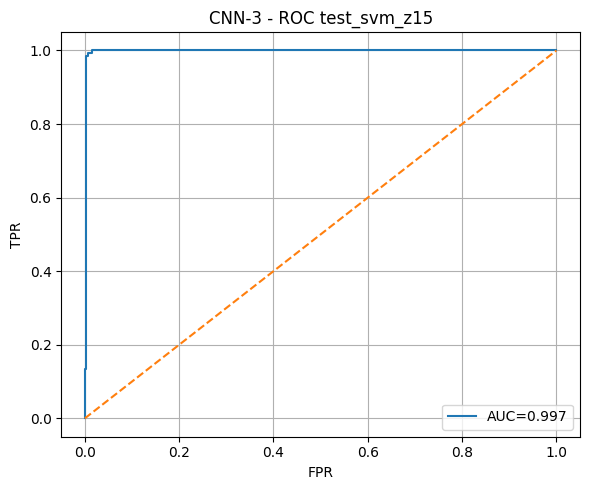

[Guardado] Results\CNN\figures\fase3_test_svm_z15_roc.png


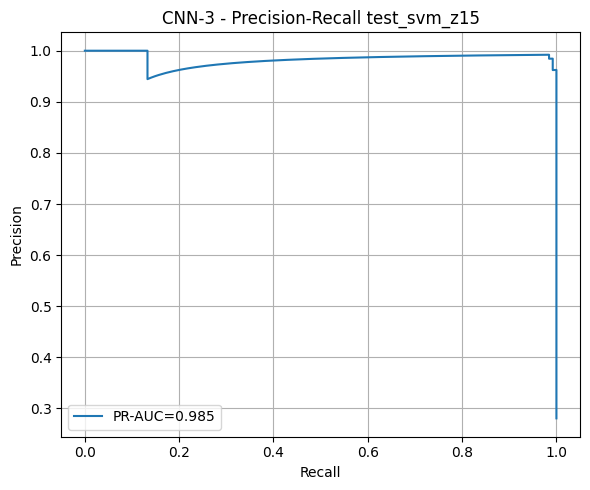

[Guardado] Results\CNN\figures\fase3_test_svm_z15_pr.png


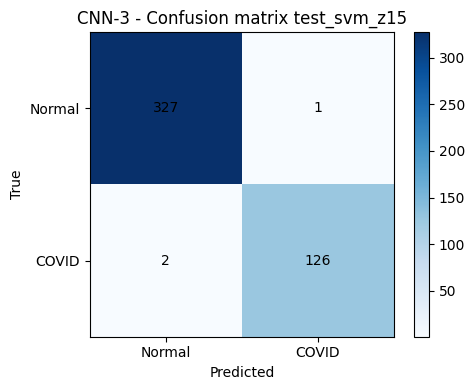

[Guardado] Results\CNN\figures\fase3_test_svm_z15_cm.png


In [58]:
plot_eval_curves(
    y_true=y_test_aux,
    probs=p_test_aux,
    threshold=thr_aux,
    split_name="test_svm_z15",
    fig_dir=FIG_DIR,
    prefix="fase3"
)

## 9.9) GUARDAR MODELO SVM

In [59]:
svm_path = os.path.join(
    LOG_DIR,
    "svm_rbf_z15.joblib"
)

joblib.dump(
    svm_z15,
    svm_path
)

print("\n[SVM guardada]")
print(svm_path)


[SVM guardada]
Results\CNN\logs\svm_rbf_z15.joblib


## 9.10) GUARDAR MÉTRICAS SVM

In [60]:
aux_results = {
    "experiment_name": EXPERIMENT_NAME,
    "model_name": MODEL_NAME,
    "aux_classifier": "SVM_RBF",
    "features": int(LATENT_DIM),

    "svm_kernel": "rbf",
    "svm_C": 1.0,
    "svm_gamma": "scale",
    "svm_class_weight": "balanced",

    "val_auc": float(val_eval_aux["auc"]),
    "val_pr_auc": float(val_eval_aux["pr_auc"]),
    "val_threshold_star": float(thr_aux),
    "val_acc_thr": float(val_eval_aux["mstar"]["acc"]),
    "val_f1_thr": float(val_eval_aux["mstar"]["f1"]),
    "val_bacc_thr": float(val_eval_aux["mstar"]["bacc"]),

    "test_auc": float(test_eval_aux["auc"]),
    "test_pr_auc": float(test_eval_aux["pr_auc"]),

    "test_acc_05": float(test_metrics_05["acc"]),
    "test_f1_05": float(test_metrics_05["f1"]),
    "test_bacc_05": float(test_metrics_05["bacc"]),

    "test_acc_thr": float(test_metrics_thr["acc"]),
    "test_f1_thr": float(test_metrics_thr["f1"]),
    "test_precision_thr": float(test_metrics_thr["precision"]),
    "test_bacc_thr": float(test_metrics_thr["bacc"]),
    "test_sensitivity_thr": float(test_metrics_thr["sensitivity"]),
    "test_specificity_thr": float(test_metrics_thr["specificity"]),
    "test_pred1_thr": float(test_metrics_thr["pred1"]),

    "tn": int(test_metrics_thr["tn"]),
    "fp": int(test_metrics_thr["fp"]),
    "fn": int(test_metrics_thr["fn"]),
    "tp": int(test_metrics_thr["tp"]),
}

aux_json = os.path.join(
    LOG_DIR,
    "fase3_svm_z15_results.json"
)

aux_csv = os.path.join(
    TABLE_DIR,
    "fase3_svm_z15_results.csv"
)

with open(aux_json, "w", encoding="utf-8") as f:
    json.dump(
        aux_results,
        f,
        indent=2,
        ensure_ascii=False
    )

pd.DataFrame([aux_results]).to_csv(
    aux_csv,
    index=False
)

print("\n[Resultados SVM guardados]")
print(aux_json)
print(aux_csv)

print("\n[OK] Sección 9 terminada.")


[Resultados SVM guardados]
Results\CNN\logs\fase3_svm_z15_results.json
Results\CNN\tables\fase3_svm_z15_results.csv

[OK] Sección 9 terminada.


# **10) VISUALIZACIÓN DEL ESPACIO LATENTE z15**
     PCA 2D / PCA 3D - CNN

In [61]:
from sklearn.decomposition import PCA

## 10.1) UNIR EMBEDDINGS TRAIN / VAL / TEST

In [62]:
Z_all = np.concatenate(
    [Z_train, Z_val, Z_test],
    axis=0
)

y_all = np.concatenate(
    [y_train, y_val, y_test],
    axis=0
)

split_all = np.array(
    ["train"] * len(y_train)
    + ["val"] * len(y_val)
    + ["test"] * len(y_test)
)

print("Z_all:", Z_all.shape)
print("y_all:", y_all.shape)
print("split_all:", split_all.shape)

Z_all: (4552, 15)
y_all: (4552,)
split_all: (4552,)


## 10.2) ESTANDARIZAR z15

In [63]:
scaler_pca = StandardScaler()

Z_all_scaled = scaler_pca.fit_transform(
    Z_all
)

print("\n[OK] z15 estandarizado para PCA")


[OK] z15 estandarizado para PCA


## 10.3) PCA 2D


In [64]:
pca2 = PCA(
    n_components=2,
    random_state=SEED
)

Z_pca2 = pca2.fit_transform(
    Z_all_scaled
)

explained_2d = pca2.explained_variance_ratio_

print("\n[PCA 2D]")
print("Explained variance ratio:", explained_2d)
print("Explained variance total:", explained_2d.sum())


df_pca2 = pd.DataFrame({
    "PC1": Z_pca2[:, 0],
    "PC2": Z_pca2[:, 1],
    "target": y_all,
    "class": np.where(y_all == 1, "COVID", "Normal"),
    "split": split_all
})

pca2_csv = os.path.join(
    TABLE_DIR,
    "fase4_pca2_z15.csv"
)

df_pca2.to_csv(
    pca2_csv,
    index=False
)

print("[Guardado]", pca2_csv)


[PCA 2D]
Explained variance ratio: [9.9935377e-01 4.9752195e-04]
Explained variance total: 0.9998513
[Guardado] Results\CNN\tables\fase4_pca2_z15.csv


## 10.4) PLOT PCA 2D - TODAS LAS PARTICIONES


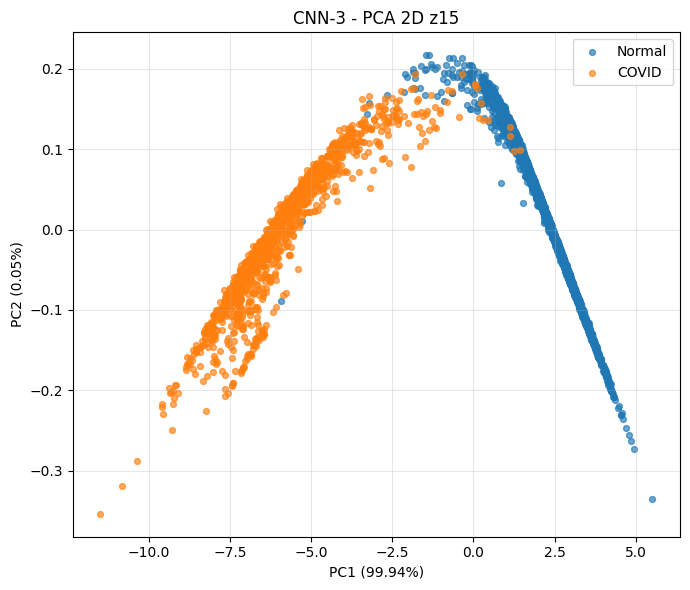

[Guardado] Results\CNN\figures\fase4_pca2_z15_all.png


In [65]:
plt.figure(figsize=(7, 6))

for cls_id, cls_name in [(0, "Normal"), (1, "COVID")]:
    mask = df_pca2["target"].values == cls_id

    plt.scatter(
        df_pca2.loc[mask, "PC1"],
        df_pca2.loc[mask, "PC2"],
        s=18,
        alpha=0.65,
        label=cls_name
    )

plt.xlabel(f"PC1 ({explained_2d[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({explained_2d[1]*100:.2f}%)")
plt.title(f"{MODEL_NAME} - PCA 2D z15")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

pca2_fig = os.path.join(
    FIG_DIR,
    "fase4_pca2_z15_all.png"
)

plt.savefig(
    pca2_fig,
    dpi=200
)

plt.show()

print("[Guardado]", pca2_fig)

## 10.5) PLOT PCA 2D POR SPLIT

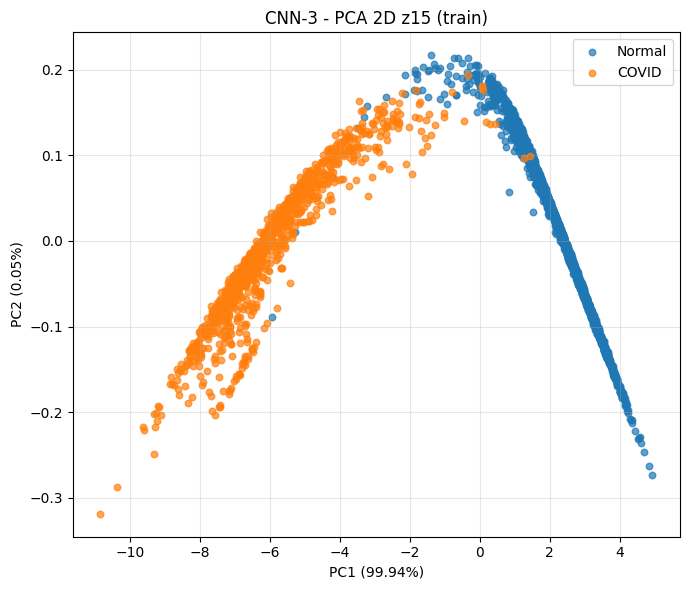

[Guardado] Results\CNN\figures\fase4_pca2_z15_train.png


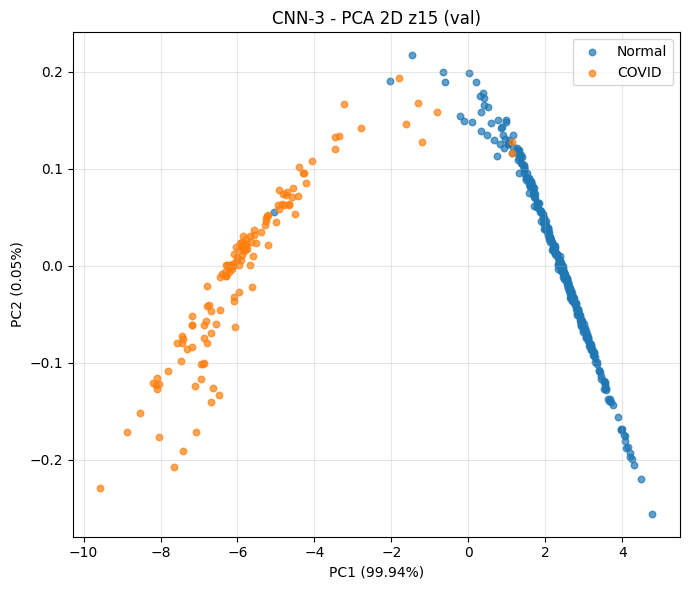

[Guardado] Results\CNN\figures\fase4_pca2_z15_val.png


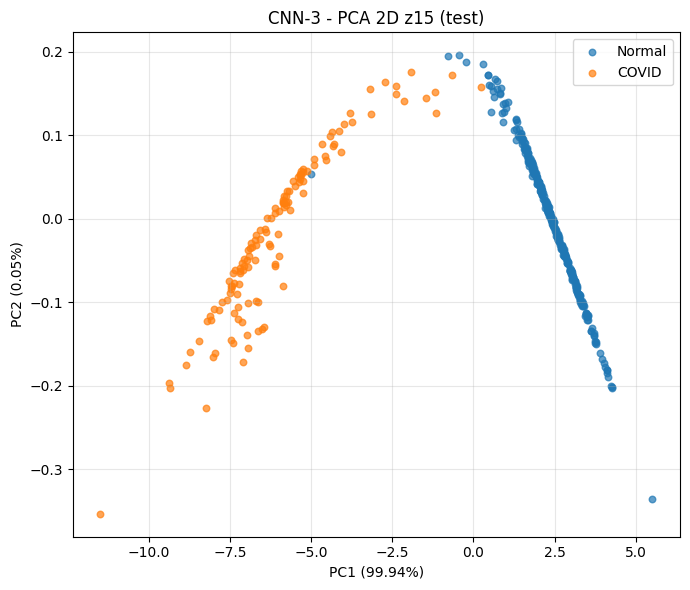

[Guardado] Results\CNN\figures\fase4_pca2_z15_test.png


In [66]:
for split_name in ["train", "val", "test"]:

    df_split = df_pca2[
        df_pca2["split"] == split_name
    ]

    plt.figure(figsize=(7, 6))

    for cls_id, cls_name in [(0, "Normal"), (1, "COVID")]:
        mask = df_split["target"].values == cls_id

        plt.scatter(
            df_split.loc[mask, "PC1"],
            df_split.loc[mask, "PC2"],
            s=22,
            alpha=0.70,
            label=cls_name
        )

    plt.xlabel(f"PC1 ({explained_2d[0]*100:.2f}%)")
    plt.ylabel(f"PC2 ({explained_2d[1]*100:.2f}%)")
    plt.title(f"{MODEL_NAME} - PCA 2D z15 ({split_name})")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    split_fig = os.path.join(
        FIG_DIR,
        f"fase4_pca2_z15_{split_name}.png"
    )

    plt.savefig(
        split_fig,
        dpi=200
    )

    plt.show()

    print("[Guardado]", split_fig)

## 10.6) PCA 3D


In [67]:
pca3 = PCA(
    n_components=3,
    random_state=SEED
)

Z_pca3 = pca3.fit_transform(
    Z_all_scaled
)

explained_3d = pca3.explained_variance_ratio_

print("\n[PCA 3D]")
print("Explained variance ratio:", explained_3d)
print("Explained variance total:", explained_3d.sum())


df_pca3 = pd.DataFrame({
    "PC1": Z_pca3[:, 0],
    "PC2": Z_pca3[:, 1],
    "PC3": Z_pca3[:, 2],
    "target": y_all,
    "class": np.where(y_all == 1, "COVID", "Normal"),
    "split": split_all
})

pca3_csv = os.path.join(
    TABLE_DIR,
    "fase4_pca3_z15.csv"
)

df_pca3.to_csv(
    pca3_csv,
    index=False
)

print("[Guardado]", pca3_csv)


[PCA 3D]
Explained variance ratio: [9.99353766e-01 4.97521949e-04 1.12908936e-04]
Explained variance total: 0.9999642
[Guardado] Results\CNN\tables\fase4_pca3_z15.csv


## 10.7) PLOT PCA 3D INTERACTIVO


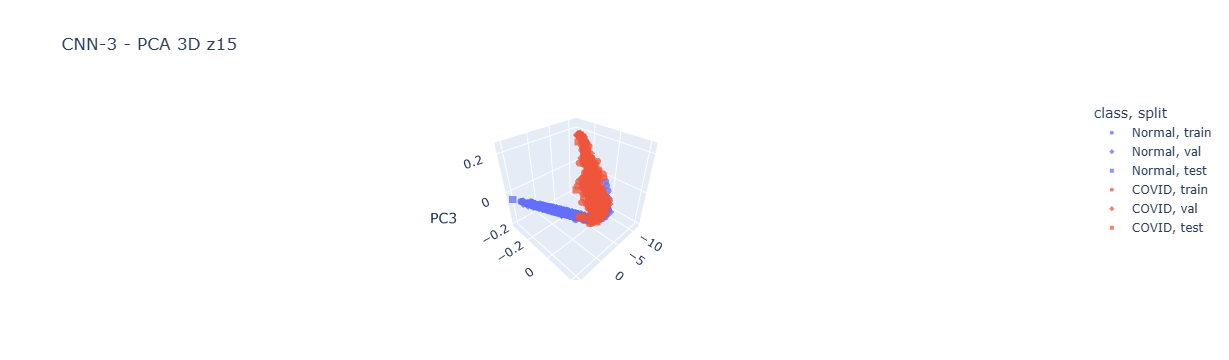

[Guardado] Results\CNN\figures\fase4_pca3_z15_interactive.html


In [68]:
try:
    import plotly.express as px

    fig = px.scatter_3d(
        df_pca3,
        x="PC1",
        y="PC2",
        z="PC3",
        color="class",
        symbol="split",
        opacity=0.75,
        title=f"{MODEL_NAME} - PCA 3D z15"
    )

    fig.update_traces(
        marker=dict(size=4)
    )

    fig.show()

    pca3_html = os.path.join(
        FIG_DIR,
        "fase4_pca3_z15_interactive.html"
    )

    fig.write_html(
        pca3_html
    )

    print("[Guardado]", pca3_html)

except Exception as e:

    print("[Aviso] No se pudo generar PCA 3D interactivo con plotly.")
    print("Error:", repr(e))


## 10.8) GUARDAR RESUMEN PCA


In [69]:
pca_summary = {
    "experiment_name": EXPERIMENT_NAME,
    "model_name": MODEL_NAME,
    "features": int(LATENT_DIM),

    "pca2_var_pc1": float(explained_2d[0]),
    "pca2_var_pc2": float(explained_2d[1]),
    "pca2_var_total": float(explained_2d.sum()),

    "pca3_var_pc1": float(explained_3d[0]),
    "pca3_var_pc2": float(explained_3d[1]),
    "pca3_var_pc3": float(explained_3d[2]),
    "pca3_var_total": float(explained_3d.sum()),
}

pca_summary_json = os.path.join(
    LOG_DIR,
    "fase4_pca_z15_summary.json"
)

pca_summary_csv = os.path.join(
    TABLE_DIR,
    "fase4_pca_z15_summary.csv"
)

with open(pca_summary_json, "w", encoding="utf-8") as f:
    json.dump(
        pca_summary,
        f,
        indent=2,
        ensure_ascii=False
    )

pd.DataFrame([pca_summary]).to_csv(
    pca_summary_csv,
    index=False
)

print("\n[Resumen PCA guardado]")
print(pca_summary_json)
print(pca_summary_csv)

print("\n[OK] Sección 10 terminada.")


[Resumen PCA guardado]
Results\CNN\logs\fase4_pca_z15_summary.json
Results\CNN\tables\fase4_pca_z15_summary.csv

[OK] Sección 10 terminada.


# **11) ANÁLISIS DE RELEVANCIA DEL ESPACIO LATENTE z15**
     Correlación + Permutation Importance usando SVM - CNN

In [70]:
from sklearn.inspection import permutation_importance

## 11.1) DATAFRAME COMPLETO z15


In [71]:
Z_all = np.concatenate(
    [Z_train, Z_val, Z_test],
    axis=0
)

y_all = np.concatenate(
    [y_train, y_val, y_test],
    axis=0
)

split_all = np.array(
    ["train"] * len(y_train)
    + ["val"] * len(y_val)
    + ["test"] * len(y_test)
)

z_cols = [f"z{i+1}" for i in range(LATENT_DIM)]

df_z_all = pd.DataFrame(
    Z_all,
    columns=z_cols
)

df_z_all["target"] = y_all
df_z_all["class"] = np.where(y_all == 1, "COVID", "Normal")
df_z_all["split"] = split_all

z_all_csv = os.path.join(
    TABLE_DIR,
    "fase5_z15_all.csv"
)

df_z_all.to_csv(
    z_all_csv,
    index=False
)

print("[Guardado]", z_all_csv)
display(df_z_all.head())

[Guardado] Results\CNN\tables\fase5_z15_all.csv


,z1,z2,z3,z4,z5,z6,z7,z8,z9,z10,z11,z12,z13,z14,z15,target,class,split
0,0.524758,0.634628,-0.664718,0.927699,0.498543,0.847345,0.585641,-0.882766,0.468984,-0.839398,0.777951,0.569359,0.557279,0.821479,-0.763652,0,Normal,train
1,1.835818,2.036454,-2.200421,2.628156,1.533847,2.378733,1.730836,-2.223315,1.388460,-2.434526,2.231734,1.922722,1.772936,2.275421,-2.174807,0,Normal,train
2,-2.546275,-2.229743,2.082574,-2.468376,-2.018742,-2.133304,-2.343478,2.019250,-2.202435,2.280331,-2.272216,-2.518813,-2.064285,-2.509834,2.231751,1,COVID,train
3,-3.304752,-2.912720,2.740347,-3.242526,-2.609743,-2.815966,-3.002781,2.634362,-2.874121,3.000938,-2.873803,-3.276174,-2.820286,-3.199349,3.052737,1,COVID,train
4,1.697461,1.849299,-1.973067,2.406501,1.395992,2.165806,1.621524,-2.054265,1.245317,-2.226473,2.028722,1.745003,1.638888,2.092482,-2.004748,0,Normal,train


## 11.2) MATRIZ DE CORRELACIÓN z15

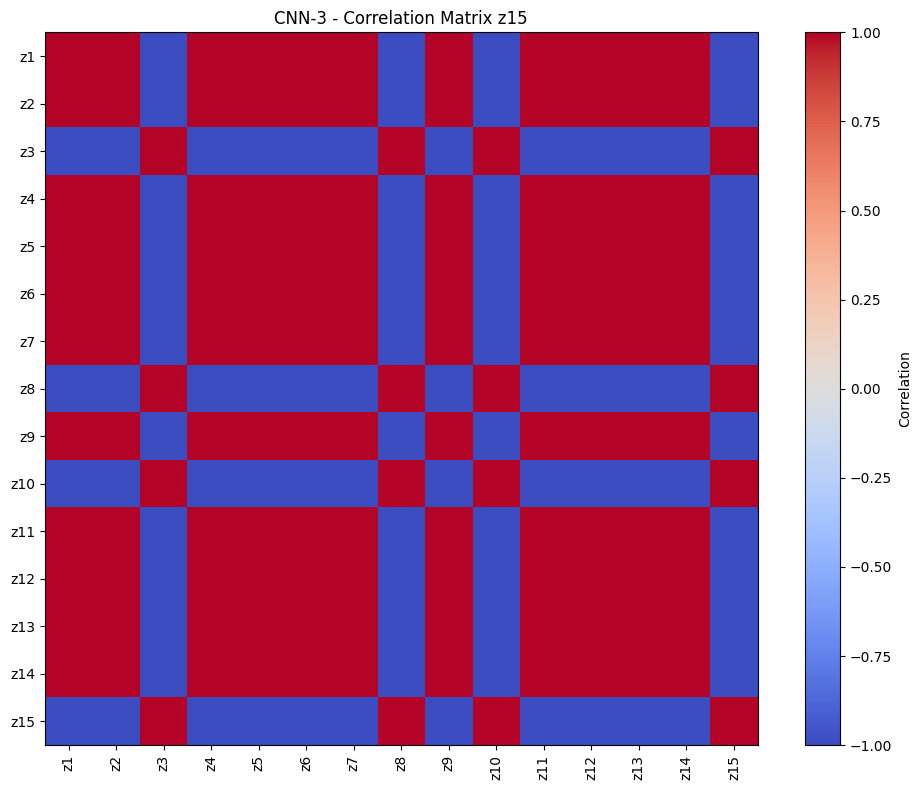

[Guardado] Results\CNN\tables\fase5_z15_correlation_matrix.csv
[Guardado] Results\CNN\figures\fase5_z15_correlation_matrix.png


In [72]:
corr_z15 = df_z_all[z_cols].corr()

corr_csv = os.path.join(
    TABLE_DIR,
    "fase5_z15_correlation_matrix.csv"
)

corr_z15.to_csv(corr_csv)

plt.figure(figsize=(10, 8))

plt.imshow(
    corr_z15.values,
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(LATENT_DIM),
    z_cols,
    rotation=90
)

plt.yticks(
    range(LATENT_DIM),
    z_cols
)

plt.title(
    f"{MODEL_NAME} - Correlation Matrix z15"
)

plt.tight_layout()

corr_fig = os.path.join(
    FIG_DIR,
    "fase5_z15_correlation_matrix.png"
)

plt.savefig(
    corr_fig,
    dpi=200
)

plt.show()

print("[Guardado]", corr_csv)
print("[Guardado]", corr_fig)

## 11.3) PERMUTATION IMPORTANCE USANDO SVM


In [73]:
print("\n[Permutation Importance]")
print("Modelo usado: svm_z15")
print("Evaluación sobre TEST")

perm = permutation_importance(
    svm_z15,
    X_test_aux,
    y_test_aux,
    scoring="balanced_accuracy",
    n_repeats=30,
    random_state=SEED,
    n_jobs=-1
)

importance_mean = perm.importances_mean
importance_std = perm.importances_std

df_importance = pd.DataFrame({
    "feature": z_cols,
    "importance_mean": importance_mean,
    "importance_std": importance_std
})

df_importance["importance_abs"] = df_importance["importance_mean"].abs()

df_importance = df_importance.sort_values(
    by="importance_abs",
    ascending=False
).reset_index(drop=True)

importance_csv = os.path.join(
    TABLE_DIR,
    "z15_svm_permutation_importance.csv"
)

df_importance.to_csv(
    importance_csv,
    index=False
)

print("[Guardado]", importance_csv)

print("\n[Top features]")
display(df_importance.head(10))


[Permutation Importance]
Modelo usado: svm_z15
Evaluación sobre TEST
[Guardado] Results\CNN\tables\z15_svm_permutation_importance.csv

[Top features]


,feature,importance_mean,importance_std,importance_abs
0,z13,0.008664,0.003724,0.008664
1,z1,0.006717,0.003701,0.006717
2,z5,0.005501,0.003044,0.005501
3,z15,0.005348,0.003005,0.005348
4,z12,0.004697,0.003498,0.004697
5,z2,0.004646,0.003554,0.004646
6,z14,0.002671,0.003477,0.002671
7,z7,0.001890,0.003126,0.001890
8,z10,0.001658,0.002751,0.001658
9,z9,0.001499,0.002963,0.001499


## 11.4) BARPLOT IMPORTANCIA MEDIA


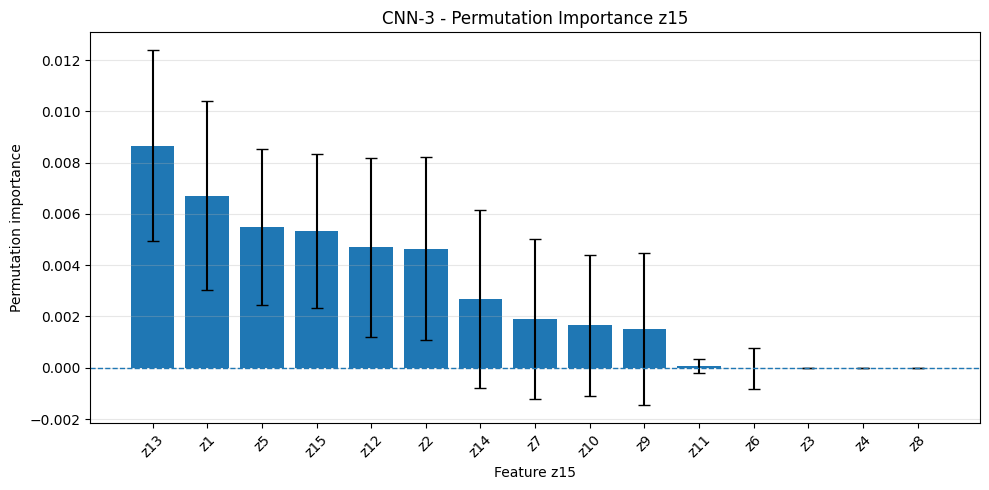

[Guardado] Results\CNN\figures\fase5_z15_permutation_importance.png


In [74]:
plt.figure(figsize=(10, 5))

plt.bar(
    df_importance["feature"],
    df_importance["importance_mean"],
    yerr=df_importance["importance_std"],
    capsize=4
)

plt.axhline(0.0, linestyle="--", linewidth=1)

plt.xlabel("Feature z15")
plt.ylabel("Permutation importance")
plt.title(
    f"{MODEL_NAME} - Permutation Importance z15"
)

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

importance_fig = os.path.join(
    FIG_DIR,
    "fase5_z15_permutation_importance.png"
)

plt.savefig(
    importance_fig,
    dpi=200
)

plt.show()

print("[Guardado]", importance_fig)

## 11.5) BARPLOT IMPORTANCIA ABSOLUTA


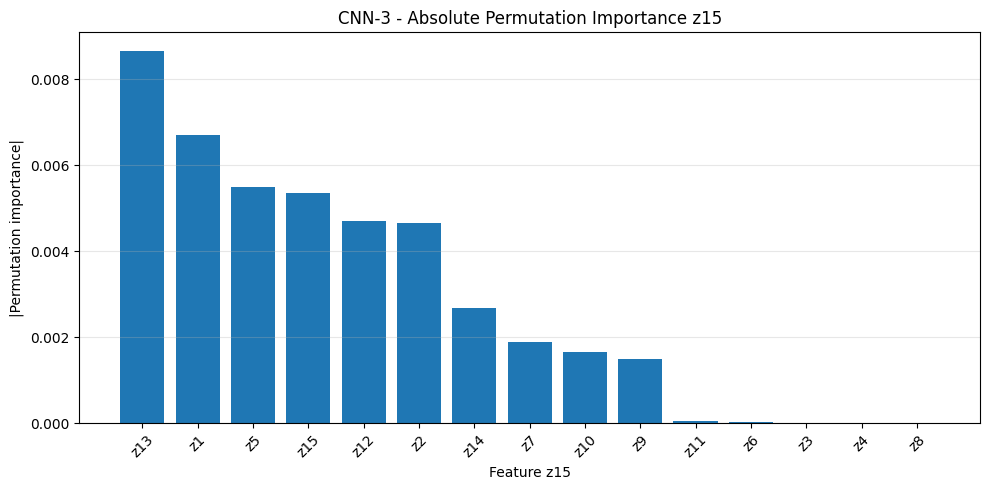

[Guardado] Results\CNN\figures\fase5_z15_absolute_permutation_importance.png


In [75]:
plt.figure(figsize=(10, 5))

plt.bar(
    df_importance["feature"],
    df_importance["importance_abs"]
)

plt.xlabel("Feature z15")
plt.ylabel("|Permutation importance|")
plt.title(
    f"{MODEL_NAME} - Absolute Permutation Importance z15"
)

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

abs_importance_fig = os.path.join(
    FIG_DIR,
    "fase5_z15_absolute_permutation_importance.png"
)

plt.savefig(
    abs_importance_fig,
    dpi=200
)

plt.show()

print("[Guardado]", abs_importance_fig)

## 11.6) GUARDAR RESUMEN DE RELEVANCIA


In [78]:
top_feature = df_importance.iloc[0]["feature"]
top_importance = df_importance.iloc[0]["importance_mean"]
top_importance_abs = df_importance.iloc[0]["importance_abs"]

relevance_summary = {
    "experiment_name": EXPERIMENT_NAME,
    "model_name": MODEL_NAME,
    "features": int(LATENT_DIM),
    "importance_method": "permutation_importance",
    "scoring": "balanced_accuracy",
    "n_repeats": 30,
    "top_feature": str(top_feature),
    "top_importance_mean": float(top_importance),
    "top_importance_abs": float(top_importance_abs),
}

relevance_json = os.path.join(
    LOG_DIR,
    "fase5_z15_relevance_summary.json"
)

relevance_csv = os.path.join(
    TABLE_DIR,
    "fase5_z15_relevance_summary.csv"
)

with open(relevance_json, "w", encoding="utf-8") as f:
    json.dump(
        relevance_summary,
        f,
        indent=2,
        ensure_ascii=False
    )

pd.DataFrame([relevance_summary]).to_csv(
    relevance_csv,
    index=False
)

print("\n[Resumen relevancia guardado]")
print(relevance_json)
print(relevance_csv)

print("\n[OK] Sección 11 terminada.")


[Resumen relevancia guardado]
Results\CNN\logs\fase5_z15_relevance_summary.json
Results\CNN\tables\fase5_z15_relevance_summary.csv

[OK] Sección 11 terminada.
